In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.size"] = 10
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["figure.dpi"] = 50

Loading the Results

In [ ]:
def load_data(filepath):
    df = pd.read_csv(filepath)

    df["Dataset"] = df["Dataset"].astype(str).str.replace(r"\['df_", "", regex=True)
    df["Dataset"] = df["Dataset"].str.replace(r"'\]", "", regex=True)

    df["RMSE"] = df["RMSE"].astype(str).str.replace(r"\[np\.float64\(|\)\]|\[|\]", "", regex=True).astype(float)
    df["MAE"] = df["MAE"].astype(str).str.replace(r"\[np\.float64\(|\)\]|\[|\]", "", regex=True).astype(float)

    return df["Dataset"].to_list(), df["RMSE"].to_list(), df["MAE"].to_list()

labels, rmse_ridge, mae_ridge = load_data("C:/Users/hinri/Desktop/Bachelorarbeit/Model Training/Ridge Regression/RidgeRegressionResults.csv")
labels, rmse_rf, mae_rf = load_data("C:/Users/hinri/Desktop/Bachelorarbeit/Model Training/Random Forrest/RandomForrestResults.csv")
labels, rmse_nn, mae_nn = load_data("C:/Users/hinri/Desktop/Bachelorarbeit/Model Training/Neural Network/NeuralNetworkResults.csv")


RMSE Scores across Datasets

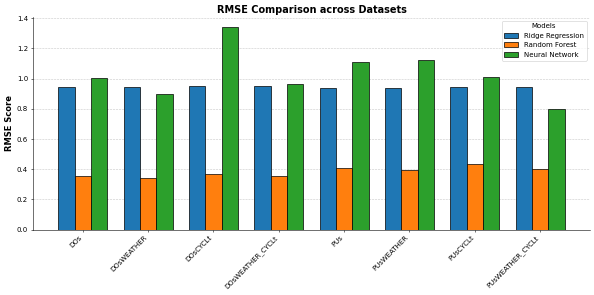

In [5]:
x = np.arange(8)

fig, ax = plt.subplots(figsize=(12,6))

ax.bar(x-0.25, rmse_ridge, 0.25, label="Ridge Regression", edgecolor="black")
ax.bar(x, rmse_rf, 0.25, label="Random Forest", edgecolor="black")
ax.bar(x+0.25, rmse_nn, 0.25, label="Neural Network", edgecolor="black")

ax.set_ylabel("RMSE Score", fontsize=12, fontweight="bold")
ax.set_title("RMSE Comparison across Datasets", fontsize=14, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=10)
ax.legend(title="Models", fontsize=10)

ax.yaxis.grid(True, linestyle="--", alpha=0.7)
ax.set_axisbelow(True)

fig.tight_layout()
plt.savefig("RMSE_values.png", dpi=300)
plt.show()

MAE Scores across Datasets

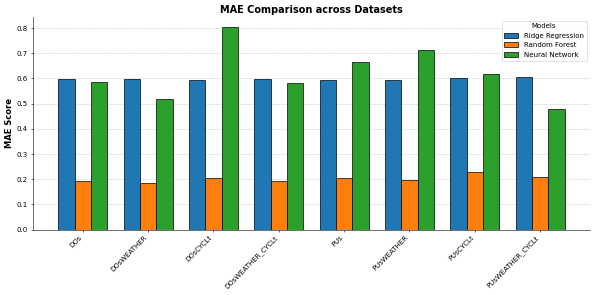

In [4]:
x = np.arange(8)

fig, ax = plt.subplots(figsize=(12,6))

ax.bar(x-0.25, mae_ridge, 0.25, label="Ridge Regression", edgecolor="black")
ax.bar(x, mae_rf, 0.25, label="Random Forest", edgecolor="black")
ax.bar(x+0.25, mae_nn, 0.25, label="Neural Network", edgecolor="black")

ax.set_ylabel("MAE Score", fontsize=12, fontweight="bold")
ax.set_title("MAE Comparison across Datasets", fontsize=14, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=10)
ax.legend(title="Models", fontsize=10)

ax.yaxis.grid(True, linestyle="--", alpha=0.7)
ax.set_axisbelow(True)

fig.tight_layout()
plt.savefig("MAE_values.png", dpi=300)
plt.show()

Tuning, Training and Testing times across different datasets and algorithms

In [24]:
def load_data(filepath):
    df = pd.read_csv(filepath)

    # Clean Dataset names
    df["Dataset"] = df["Dataset"].astype(str).str.replace(r"\['df_", "", regex=True)
    df["Dataset"] = df["Dataset"].str.replace(r"'\]", "", regex=True)

    # Clean Tuning Time Column
    df["Tuning_Time_sec"] = df["Tuning_Time_sec"].astype(str).str.replace(r"\[|\]", "", regex=True).astype(float)

    # Return only labels and tuning times
    return df["Dataset"].to_list(), df["Tuning_Time_sec"].to_list()

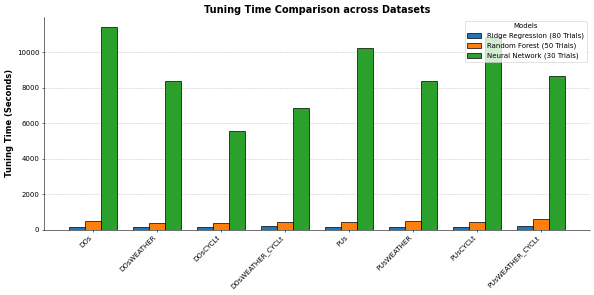

In [25]:
from matplotlib.patches import Patch

labels, tune_ridge = load_data("C:/Users/hinri/Desktop/Bachelorarbeit/Model Training/Ridge Regression/RidgeRegressionResults.csv")
labels, tune_rf = load_data("C:/Users/hinri/Desktop/Bachelorarbeit/Model Training/Random Forrest/RandomForrestResults.csv")
labels, tune_nn = load_data("C:/Users/hinri/Desktop/Bachelorarbeit/Model Training/Neural Network/NeuralNetworkResults.csv")

#tune_ridge, train_ridge, test_ridge = np.array(tune_ridge), np.array(train_ridge), np.array(test_ridge)
#tune_rf, train_rf, test_rf = np.array(tune_rf), np.array(train_rf), np.array(test_rf)
#tune_nn, train_nn, test_nn = np.array(tune_nn), np.array(train_nn), np.array(test_nn)

x = np.arange(8)

fig, ax = plt.subplots(figsize=(12,6))

# Plot the tuning times side-by-side
ax.bar(x - 0.25, tune_ridge, 0.25, label="Ridge Regression (80 Trials)", edgecolor="black")
ax.bar(x, tune_rf, 0.25, label="Random Forest (50 Trials)", edgecolor="black")
ax.bar(x + 0.25, tune_nn, 0.25, label="Neural Network (30 Trials)", edgecolor="black")

# Formatting
ax.set_ylabel("Tuning Time (Seconds)", fontsize=12, fontweight="bold")
ax.set_title("Tuning Time Comparison across Datasets", fontsize=14, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=10)
ax.legend(title="Models", fontsize=10)

ax.yaxis.grid(True, linestyle="--", alpha=0.7)
ax.set_axisbelow(True)

fig.tight_layout()
plt.savefig("Tuning_Times.png", dpi=300)
plt.show()

In [26]:
def load_data(filepath):
    df = pd.read_csv(filepath)

    df["Dataset"] = df["Dataset"].astype(str).str.replace(r"\['df_", "", regex=True)
    df["Dataset"] = df["Dataset"].str.replace(r"'\]", "", regex=True)

    df["Training_Time_sec"] = df["Training_Time_sec"].astype(str).str.replace(r"\[|\]", "", regex=True).astype(float)
    df["Testing_Time_sec"] = df["Testing_Time_sec"].astype(str).str.replace(r"\[|\]", "", regex=True).astype(float)

    return df["Dataset"].to_list(), df["Training_Time_sec"].to_list(), df["Testing_Time_sec"].to_list()

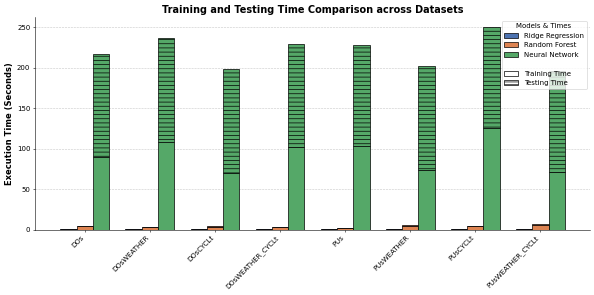

In [27]:
# Load data using your exact file paths
labels, train_ridge, test_ridge = load_data("C:/Users/hinri/Desktop/Bachelorarbeit/Model Training/Ridge Regression/RidgeRegressionResults.csv")
labels, train_rf, test_rf = load_data("C:/Users/hinri/Desktop/Bachelorarbeit/Model Training/Random Forrest/RandomForrestResults.csv")
labels, train_nn, test_nn = load_data("C:/Users/hinri/Desktop/Bachelorarbeit/Model Training/Neural Network/NeuralNetworkResults.csv")

# Convert lists to numpy arrays to allow mathematical addition for the 'bottom' parameter
train_ridge, test_ridge = np.array(train_ridge), np.array(test_ridge)
train_rf, test_rf = np.array(train_rf), np.array(test_rf)
train_nn, test_nn = np.array(train_nn), np.array(test_nn)

x = np.arange(len(labels))

fig, ax = plt.subplots(figsize=(12, 6))

# Define model colors
c_ridge = '#4C72B0'  # Blue
c_rf = '#DD8452'     # Orange
c_nn = '#55A868'     # Green

# Plot Ridge Regression (Left)
ax.bar(x - 0.25, train_ridge, 0.25, color=c_ridge, edgecolor="black")
ax.bar(x - 0.25, test_ridge, 0.25, bottom=train_ridge, color=c_ridge, edgecolor="black", hatch="--")

# Plot Random Forest (Center)
ax.bar(x, train_rf, 0.25, color=c_rf, edgecolor="black")
ax.bar(x, test_rf, 0.25, bottom=train_rf, color=c_rf, edgecolor="black", hatch="--")

# Plot Neural Network (Right)
ax.bar(x + 0.25, train_nn, 0.25, color=c_nn, edgecolor="black")
ax.bar(x + 0.25, test_nn, 0.25, bottom=train_nn, color=c_nn, edgecolor="black", hatch="--")

# Formatting
ax.set_ylabel("Execution Time (Seconds)", fontsize=12, fontweight="bold")
ax.set_title("Training and Testing Time Comparison across Datasets", fontsize=14, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=10)

ax.yaxis.grid(True, linestyle="--", alpha=0.7)
ax.set_axisbelow(True)

# Custom legend to explain colors (Models) and patterns (Train vs Test)
legend_elements = [
    Patch(facecolor=c_ridge, edgecolor="black", label="Ridge Regression"),
    Patch(facecolor=c_rf, edgecolor="black", label="Random Forest"),
    Patch(facecolor=c_nn, edgecolor="black", label="Neural Network"),
    Patch(facecolor="white", edgecolor="white", label=""),  # Spacer
    Patch(facecolor="white", edgecolor="black", label="Training Time"),
    Patch(facecolor="white", edgecolor="black", hatch="---", label="Testing Time")
]

ax.legend(handles=legend_elements, title="Models & Times", fontsize=10)

fig.tight_layout()
plt.savefig("Train_Test_Times.png", dpi=300)
plt.show()

Average Hyperparameter Importance for FFNN

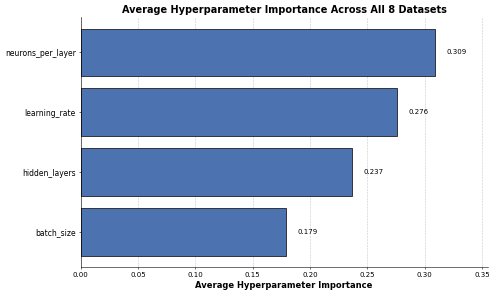

In [35]:
import optuna
import matplotlib.pyplot as plt
import numpy as np

storage_path = "sqlite:///C:/Users/hinri/Desktop/Bachelorarbeit/Model Training/Neural Network/FFNN_tuning.db"

study_names = [
    "NN_df_DOs", "NN_df_DOsWEATHER", "NN_df_DOsCYCLt", "NN_df_DOsWEATHER_CYCLt",
    "NN_df_PUs", "NN_df_PUsWEATHER", "NN_df_PUsCYCLt", "NN_df_PUsWEATHER_CYCLt"
]

param_sums = {}


for name in study_names:
    study = optuna.load_study(study_name=name, storage=storage_path)
    importances = optuna.importance.get_param_importances(study)
    
    for param, value in importances.items():
        # Initialize the parameter if it's the first study
        if param not in param_sums:
            param_sums[param] = 0
        param_sums[param] += value

# Divide every sum by exactly 8 (the number of studies)
avg_importances = {param: total / len(study_names) for param, total in param_sums.items()}

# Sort the parameters so the most important is at the top of the graph
sorted_params = sorted(avg_importances.items(), key=lambda x: x[1])
labels = [item[0] for item in sorted_params]
values = [item[1] for item in sorted_params]

fig, ax = plt.subplots(figsize=(10, 6))

y_pos = np.arange(len(labels))
ax.barh(y_pos, values, color="#4C72B0", edgecolor="black")

# Formatting
ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=11)
ax.set_xlabel("Average Hyperparameter Importance", fontsize=12, fontweight="bold")
ax.set_title("Average Hyperparameter Importance Across All 8 Datasets", fontsize=14, fontweight="bold")

# Add percentage labels to the end of each bar for extra clarity
for i, v in enumerate(values):
    ax.text(v + 0.01, i, f"{v:.3f}", va='center', fontsize=10)

ax.xaxis.grid(True, linestyle="--", alpha=0.7)
ax.set_axisbelow(True)
# Ensure the x-axis starts at 0 and goes slightly past the max value
ax.set_xlim(0, max(values) * 1.15) 

fig.tight_layout()
plt.savefig("HyperpImp_FFNN_Avg.png", dpi=300)
plt.show()